# Beryllium in water
Simulations were run at 350 K for 50 ps.

The system contained 112 water molecules and one Be2+/BeCl2 unit, resulting in a 1 M concentration.

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os


import utils.helper_funcs as hf
#import utils.thermo_funcs as tf


from ase.io import read

data_path = '../data'

MP0_paths = {
    'Be$^{2+}$(aq)':'/MACE-MP-0/112_water/Be2+/',
    'BeCl$_2$(aq)':'/MACE-MP-0/112_water/BeCl2/',
}
POLAR_paths = {
    'Be$^{2+}$(aq)':'/MACE-POLAR-1-M/112_water_Be/Be2+/',
    'BeCl$_2$(aq)':'/MACE-POLAR-1-M/112_water_Be/BeCl2/',
}

plt.rcParams.update({'font.size': 14})

# Structure

## MACE-MP-0

In [ ]:
MP0_rdf_data = hf.load_data(MP0_paths, root_dir=data_path, fname='travis/rdf_Be_O_[Be1r_O1o].csv')

Loading data for 'Be$^{2+}$(aq)' from '../data/MACE-MP-0/112_water/Be2+/travis/rdf_Be_O_[Be1r_O1o].csv'
Loading data for 'BeCl$_2$(aq)' from '../data/MACE-MP-0/112_water/BeCl2/travis/rdf_Be_O_[Be1r_O1o].csv'


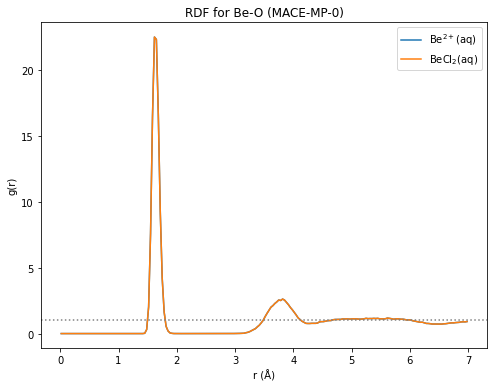

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
for key, data in MP0_rdf_data.items():
    ax.plot(data['# Distance / pm']/100, data['  g(r)'], label=key)
    rmax = data['# Distance / pm'].max()/100
ax.set_title(f'RDF for Be-O (MACE-MP-0)')
ax.set_xlabel('r (Å)')
ax.set_ylabel('g(r)')
ax.axhline(1, 0, rmax, color='gray', linestyle=':')
ax.legend()
plt.show()

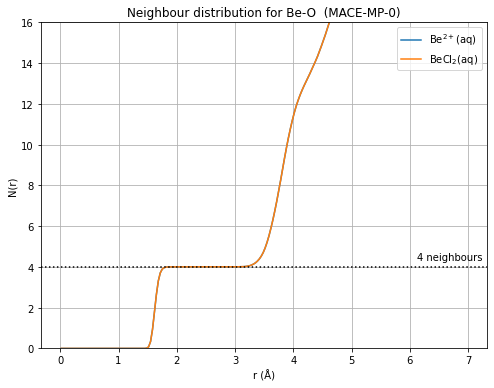

In [4]:
fig, ax = plt.subplots(figsize=(8, 6))
for key, data in MP0_rdf_data.items():
    ax.plot(data['# Distance / pm']/100, data['  Integral'], label=key)

y = 4
ax.axhline(4, 0, color='black', linestyle=':')
plt.annotate(
    f"{y} neighbours",
    xy=(1-0.01, y+0.5),
    xycoords=('axes fraction', 'data'),
    ha='right',
    va='center'
)

ax.set_title(f'Neighbour distribution for Be-O  (MACE-MP-0)')
ax.set_xlabel('r (Å)')
ax.set_ylabel('N(r)')
ax.set_ylim(0, 16)
ax.grid()
ax.legend()
plt.show()

## MACE-POLAR-1-M
SIMULATIONS ARE NOT YET FINISHED

In [11]:
POLAR_rdf_data = hf.load_data(POLAR_paths, root_dir=data_path, fname='travis/rdf_Be_O_[Be1r_O1o].csv')

Loading data for 'Be$^{2+}$(aq)' from '../data/MACE-POLAR-1-M/112_water_Be/Be2+/travis/rdf_Be_O_[Be1r_O1o].csv'
Loading data for 'BeCl$_2$(aq)' from '../data/MACE-POLAR-1-M/112_water_Be/BeCl2/travis/rdf_Be_O_[Be1r_O1o].csv'


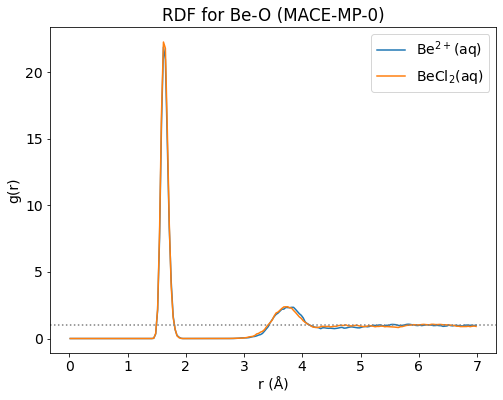

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
for key, data in POLAR_rdf_data.items():
    ax.plot(data['# Distance / pm']/100, data['  g(r)'], label=key)
    rmax = data['# Distance / pm'].max()/100
ax.set_title(f'RDF for Be-O (MACE-MP-0)')
ax.set_xlabel('r (Å)')
ax.set_ylabel('g(r)')
ax.axhline(1, 0, rmax, color='gray', linestyle=':')
ax.legend()
plt.show()

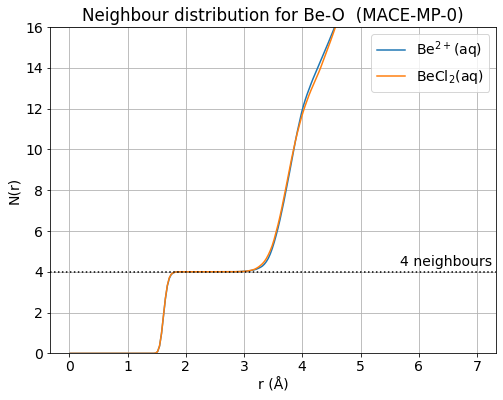

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
for key, data in POLAR_rdf_data.items():
    ax.plot(data['# Distance / pm']/100, data['  Integral'], label=key)

y = 4
ax.axhline(4, 0, color='black', linestyle=':')
plt.annotate(
    f"{y} neighbours",
    xy=(1-0.01, y+0.5),
    xycoords=('axes fraction', 'data'),
    ha='right',
    va='center'
)

ax.set_title(f'Neighbour distribution for Be-O  (MACE-MP-0)')
ax.set_xlabel('r (Å)')
ax.set_ylabel('N(r)')
ax.set_ylim(0, 16)
ax.grid()
ax.legend()
plt.show()

## MACE-POLAR-1-M vs MACE-MP-0

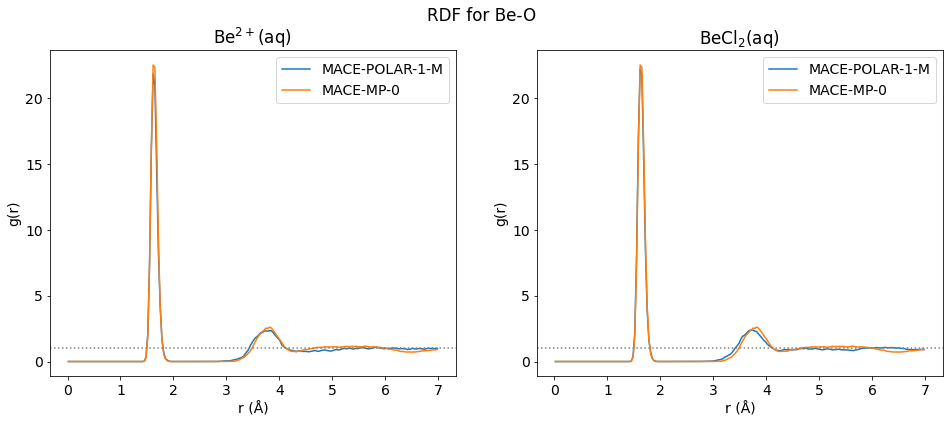

In [33]:
fig, axs = plt.subplots(1, 2, figsize=(8*2, 6))
fig.suptitle(f'RDF for Be-O')
for i, key in enumerate(POLAR_rdf_data):
    r = POLAR_rdf_data[key]['# Distance / pm']/100
    axs[i].set_title(key)
    axs[i].set_xlabel('r (Å)')
    axs[i].set_ylabel('g(r)')

    axs[i].plot(r, POLAR_rdf_data[key]['  g(r)'], label='MACE-POLAR-1-M')
    axs[i].plot(r, MP0_rdf_data[key]['  g(r)'], label='MACE-MP-0')
    rmax = POLAR_rdf_data[key]['# Distance / pm'].max()/100

    axs[i].legend()
    axs[i].axhline(1, 0, rmax, color='gray', linestyle=':')
plt.show()

Be$^{2+}$(aq)
BeCl$_2$(aq)


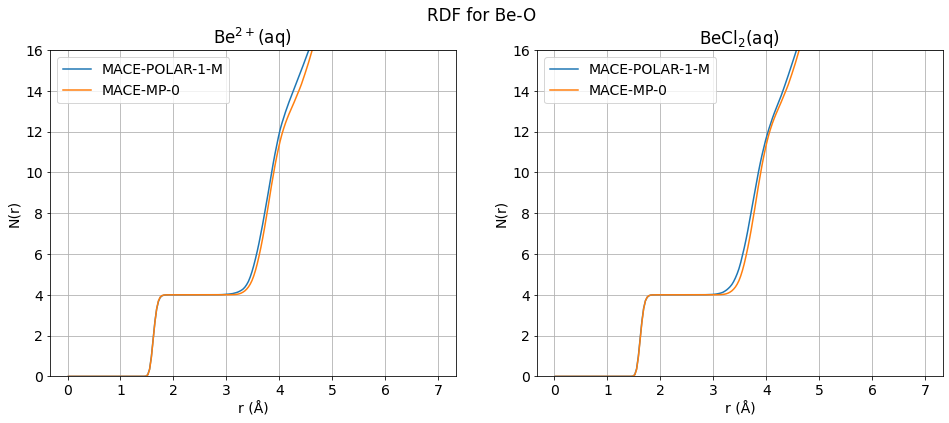

In [36]:
fig, axs = plt.subplots(1, 2, figsize=(8*2, 6))
fig.suptitle(f'RDF for Be-O')
for i, key in enumerate(POLAR_rdf_data):
    print(key)
    r = POLAR_rdf_data[key]['# Distance / pm']/100
    axs[i].set_title(key)
    axs[i].set_xlabel('r (Å)')
    axs[i].set_ylabel('N(r)')
    axs[i].set_ylim(0, 16)
    axs[i].grid()

    axs[i].plot(r, POLAR_rdf_data[key]['  Integral'], label='MACE-POLAR-1-M')
    axs[i].plot(r, MP0_rdf_data[key]['  Integral'], label='MACE-MP-0')
    rmax = POLAR_rdf_data[key]['# Distance / pm'].max()/100

    axs[i].legend()
plt.show()

# Thermodynamic properties

## MACE-MP-0

In [6]:
MP0_thermo_df = hf.cached_thermo_props(
    'results/beryllium/MP0_thermo_props.json',
    MP0_paths, 
    data_path, 
    temperature=350.0, 
    correlation_times={"density": 500, "heat_capacity": 500, "compressibility": 500, "bulk_modulus": 500, "thermal_expansion": 500},
    block_factor=5,
)
MP0_thermo_df

Loaded thermodynamic properties from results/beryllium/MP0_thermo_props.json


## MACE-POLAR-1-M
SIMULATIONS ARE NOT YET FINISHED

In [41]:
POLAR_thermo_df = hf.cached_thermo_props(
    'results/beryllium/POLAR_thermo_props.json',
    POLAR_paths, 
    data_path, 
    temperature=350.0, 
    correlation_times={"density": 500, "heat_capacity": 500, "compressibility": 500, "bulk_modulus": 500, "thermal_expansion": 500},
    block_factor=2,
)
POLAR_thermo_df

Loaded thermodynamic properties from results/beryllium/POLAR_thermo_props.json
